<a href="https://colab.research.google.com/github/RenatGreen-flag/Model-Liniar-Regression/blob/main/linearRegressionGoldnIDR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prediksi Harga Emas dalam Rupiah (IDR)**
Menggunakan Algoritma Regresi Linear Berbasis Data yfinance


---

Pada nootbook ini saya akan membangun model prediksi harga emas menggunakan pendekatan **Regresi Linear** dengan data historis yang diunduh langsung dari Yahoo Finance melalui **library yfinance**.

**Alur Kerja:**


1. Import dan Eksplorasi Data (EDA) menggunakan library ydata_profiling
2. Feature Engineering
3. Pre-Processing Data
4. Pelatihan Model
5. Evaluasi & Analisis Overfitting
6. Hyperparameter Tuning (Ridge & Lasso)
7. Percobaan Prediksi
8. Kesimpulan





In [161]:
# Install library yang diperlukan (Jalankan Sekali)

!pip install ydata-profiling
!pip install yfinance

# **INFORMASI DATASET**

Dataset ini berisi data historis **Harga Emas Dunia dan Indeks USD/IDR** yang dikumpulkan oleh Yahoo Finance dalam rentang waktu **2023 hingga sekarang**.

**Sumber Data**: Yahoo Finance - Gold Price, Indeks USD/IDR (2023-Sekarang)

| Ticker | Deskripsi | Satuan |
|--------|-----------|--------|
| `GC=F` | Gold Futures (Harga Emas Dunia) | USD/troy oz |
| `USDIDR=X` | Kurs USD terhadap Rupiah | IDR per 1 USD |

Rentang data 1 Januari 2023 - 29 Juni 2026

Harga emas akhirnya akan dikonversi ke IDR dengan rumus:
> Harga Emas (IDR/gram) = Harga Emas (USD/troy oz) x Kurs USD/IDR / 31.1035








In [162]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# digunakan untuk memberitahu dan mengatur peringatan fitur yg usang
import warnings
warnings.filterwarnings('ignore')

**# Langkah 1 Mengambil Data Dari Library YFinance**



1.   Ambil data harga emas dan indeks nilsi tukar USD/IDR
2.   Gunakan ticker symbol yang tersedia di yfinance.
3. Gunakan dictionary untuk memudahkan pengambilan data.
4. Tentukan rentang pengambilan data, saya menggunakan data historis dari januari 2023 - sekarang.




In [163]:
# untuk konversi ounce ke gram
TROY_OUNCE_TO_GRAM = 31.1035   # 1 troy ounce = 31.1035 gram
pd.set_option('display.float_format', lambda x: '%.2f' % x) # agar floar tidak terlalu panjang
ticker_map = {
    "GC=F"    : "gold",
    "USDIDR=X": "usdidr",
}

START = "2023-01-01"
END   = datetime.today().strftime("%Y-%m-%d")

raw = yf.download(
    tickers     = list(ticker_map.keys()),
    start       = START,
    end         = END,
    auto_adjust = True,
    progress    = True,
    group_by    = 'ticker'
)

print(f"\n✅ Data Emas   : {raw.shape[0]} baris, {raw["GC=F"].shape[1]} kolom")
print(f"✅ Data USD/IDR: {raw.shape[0]} baris, {raw["USDIDR=X"].shape[1]} kolom")

print("\nPreview Data Harga Emas berdasarkan Data Yahoo Finance")
display(raw["GC=F"].tail())
print("\nPreview Data Kurs USD /IDR berdasarkan Data Yahoo Finance")
display(raw["USDIDR=X"].head())


[*********************100%***********************]  2 of 2 completed


✅ Data Emas   : 907 baris, 5 kolom
✅ Data USD/IDR: 907 baris, 5 kolom

Preview Data Harga Emas berdasarkan Data Yahoo Finance


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-06-23,4127.10,4135.20,4118.50,4129.90,252.00
2026-06-24,4104.40,4104.70,3963.30,3990.30,353.00
2026-06-25,3988.40,4030.50,3986.70,4030.50,2724.00
2026-06-26,4078.70,4078.70,4078.70,4078.70,1431.00
2026-06-29,4057.50,4070.00,4003.20,4022.30,1431.00



Preview Data Kurs USD /IDR berdasarkan Data Yahoo Finance


Price,Open,High,Low,Close,Volume
Date,,,,,
2023-01-02,15508.80,15588.70,15463.90,15508.80,0.00
2023-01-03,15550.00,15638.80,15514.90,15550.00,0.00
2023-01-04,15571.80,15627.50,15553.50,15571.80,0.00
2023-01-05,15560.00,15640.90,15558.50,15560.00,0.00
2023-01-06,15620.00,15692.10,15558.10,15620.00,0.00


# Penggabungan dan Konversi Rupiah



In [164]:
# mengambil semua kolom dan menambahkan suffix '_Gold_USD' ke setiap kolom
gold_close = raw['GC=F'].add_suffix('_Gold_USD')
usdidr_close = raw['USDIDR=X'].add_suffix('_usdidr')

# hapus kolom yang tidak diperlukan
usdidr_close.drop(columns=['Volume_usdidr'], inplace=True)

# gabungkan berdasarkan tanggal
df = gold_close.join(usdidr_close, how='inner')
df = df.ffill().dropna()

# Konversi ke rupiah / gram
df["Gold_Close_IDR"] = df["Close_Gold_USD"] * df["Close_usdidr"] / TROY_OUNCE_TO_GRAM
df["Gold_High_IDR"] = df["High_Gold_USD"] * df["High_usdidr"] / TROY_OUNCE_TO_GRAM
df["Gold_Low_IDR"] = df["Low_Gold_USD"] * df["Low_usdidr"] / TROY_OUNCE_TO_GRAM
df["Gold_Open_IDR"] = df["Open_Gold_USD"] * df["Open_usdidr"] / TROY_OUNCE_TO_GRAM

print(f"Total data setelah penggabungan: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Rentang tanggal: {df.index.min().date()} s/d {df.index.max().date()}")
display(df.head())




Total data setelah penggabungan: 906 baris, 13 kolom
Rentang tanggal: 2023-01-03 s/d 2026-06-29


Price,Open_Gold_USD,High_Gold_USD,Low_Gold_USD,Close_Gold_USD,Volume_Gold_USD,Open_usdidr,High_usdidr,Low_usdidr,Close_usdidr,Gold_Close_IDR,Gold_High_IDR,Gold_Low_IDR,Gold_Open_IDR
Date,,,,,,,,,,,,,
2023-01-03,1836.20,1839.70,1836.20,1839.70,29.00,15550.00,15638.80,15514.90,15550.00,919746.47,924998.77,915924.55,917996.66
2023-01-04,1845.60,1859.10,1845.60,1852.80,25.00,15571.80,15627.50,15553.50,15571.80,927594.37,934077.67,922903.83,923989.69
2023-01-05,1855.20,1855.20,1834.80,1834.80,24.00,15560.00,15640.90,15558.50,15560.00,917886.69,932917.44,917798.21,928092.06
2023-01-06,1838.40,1868.20,1835.30,1864.20,26.00,15620.00,15692.10,15558.10,15620.00,936190.56,942529.93,918024.69,923233.99
2023-01-09,1867.00,1880.00,1867.00,1872.70,62.00,15602.30,15626.00,15545.80,15602.30,939393.51,944487.92,933142.84,936534.27


# 2. Exploratory Data Analysis (EDA)

>***1. Pahami informasi dasar & missing value***

In [165]:
print("\nInformasi Dataset")
print(df.info())
print("\n Statistik Deskriptif")
display(df.describe().round(2))
print("\nJumlah missing value per kolom")
print(df.isnull().sum())


Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 906 entries, 2023-01-03 to 2026-06-29
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open_Gold_USD    906 non-null    float64
 1   High_Gold_USD    906 non-null    float64
 2   Low_Gold_USD     906 non-null    float64
 3   Close_Gold_USD   906 non-null    float64
 4   Volume_Gold_USD  906 non-null    float64
 5   Open_usdidr      906 non-null    float64
 6   High_usdidr      906 non-null    float64
 7   Low_usdidr       906 non-null    float64
 8   Close_usdidr     906 non-null    float64
 9   Gold_Close_IDR   906 non-null    float64
 10  Gold_High_IDR    906 non-null    float64
 11  Gold_Low_IDR     906 non-null    float64
 12  Gold_Open_IDR    906 non-null    float64
dtypes: float64(13)
memory usage: 99.1 KB
None

 Statistik Deskriptif


Price,Open_Gold_USD,High_Gold_USD,Low_Gold_USD,Close_Gold_USD,Volume_Gold_USD,Open_usdidr,High_usdidr,Low_usdidr,Close_usdidr,Gold_Close_IDR,Gold_High_IDR,Gold_Low_IDR,Gold_Open_IDR
count,906.00,906.00,906.00,906.00,906.00,906.00,906.00,906.00,906.00,906.00,906.00,906.00,906.00
mean,2883.99,2902.26,2865.28,2884.05,4249.19,16023.14,16085.30,15935.13,16027.89,1505463.43,1520616.78,1487438.09,1504983.51
std,985.58,996.72,970.85,983.21,20703.89,725.78,727.29,746.96,722.81,576386.11,586165.42,568957.54,577698.78
min,1808.10,1808.80,1808.10,1808.80,0.00,14581.30,14682.50,13082.00,14663.00,884525.82,888236.05,821297.31,884125.34
25%,2007.20,2018.15,1996.60,2011.05,94.00,15457.00,15532.27,15347.10,15460.65,997642.15,1009768.77,982895.18,999040.54
50%,2597.10,2610.50,2589.80,2603.00,355.50,16055.85,16189.25,15929.75,16090.30,1287453.08,1301992.62,1274420.58,1288878.17
75%,3385.30,3409.92,3365.78,3393.03,983.25,16555.42,16605.85,16435.77,16552.27,1786519.49,1806630.68,1769618.07,1790654.91
max,5415.70,5586.20,5301.60,5318.40,202373.00,18199.00,18222.00,17953.10,18190.30,2859438.39,3020249.67,2844497.78,2911751.91



Jumlah missing value per kolom
Price
Open_Gold_USD      0
High_Gold_USD      0
Low_Gold_USD       0
Close_Gold_USD     0
Volume_Gold_USD    0
Open_usdidr        0
High_usdidr        0
Low_usdidr         0
Close_usdidr       0
Gold_Close_IDR     0
Gold_High_IDR      0
Gold_Low_IDR       0
Gold_Open_IDR      0
dtype: int64


***2. Visualisasi Tren Harga Emas (USD & IDR)***


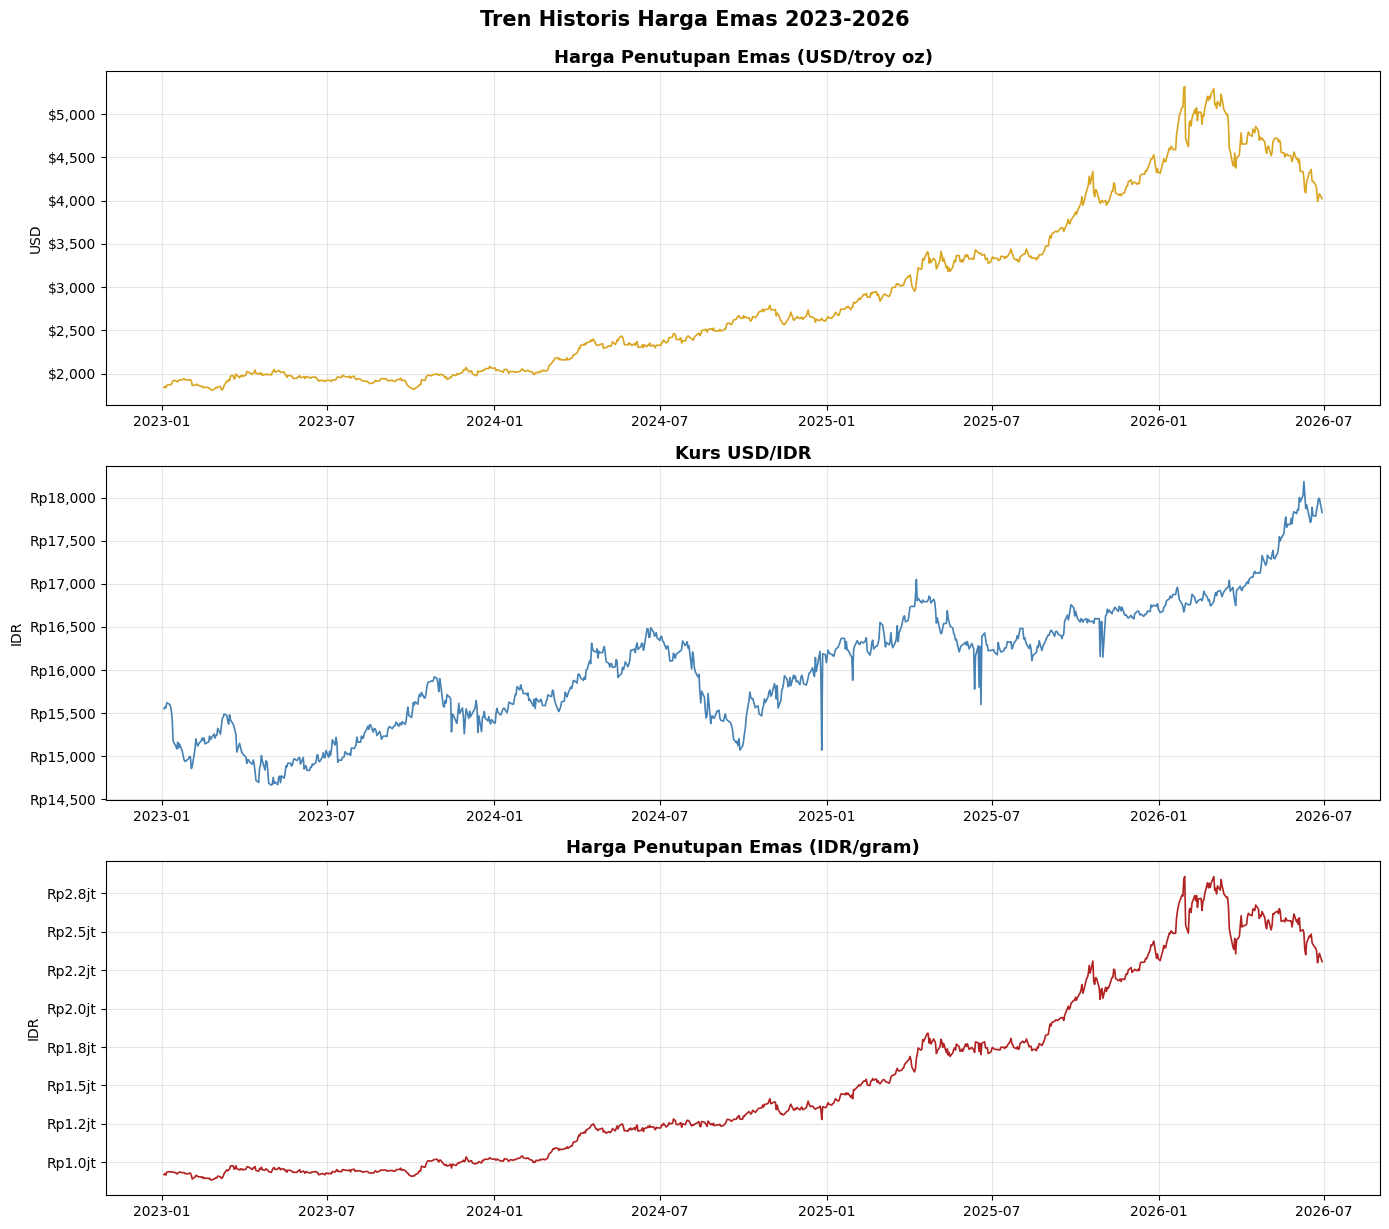

In [166]:
fig, axes = plt.subplots(3,1, figsize=(14, 12))

# Plot 1 : Harga emas dalam USD
axes[0].plot(df.index, df["Close_Gold_USD"], color='goldenrod', linewidth=1.2)
axes[0].set_title('Harga Penutupan Emas (USD/troy oz)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[0].grid(alpha=0.3)

# Plot 2 : Kurs USD?IDR
axes[1].plot(df.index, df["Close_usdidr"], color='steelblue', linewidth=1.2)
axes[1].set_title('Kurs USD/IDR', fontsize=13, fontweight='bold')
axes[1].set_ylabel('IDR')
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('Rp{x:,.0f}'))
axes[1].grid(alpha=0.3)

# Plot 3 : Harga emas dalam Rupiah (IDR)
axes[2].plot(df.index, df["Gold_Close_IDR"], color='firebrick', linewidth=1.2)
axes[2].set_title('Harga Penutupan Emas (IDR/gram)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('IDR')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp{x/1e6:,.1f}jt'))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Tren Historis Harga Emas 2023-2026', fontsize=15, y=1.02, fontweight='bold')
plt.savefig('/tmp/trend_emas.png', dpi=120, bbox_inches='tight')
plt.show()

***3. Analisis Korelasi***

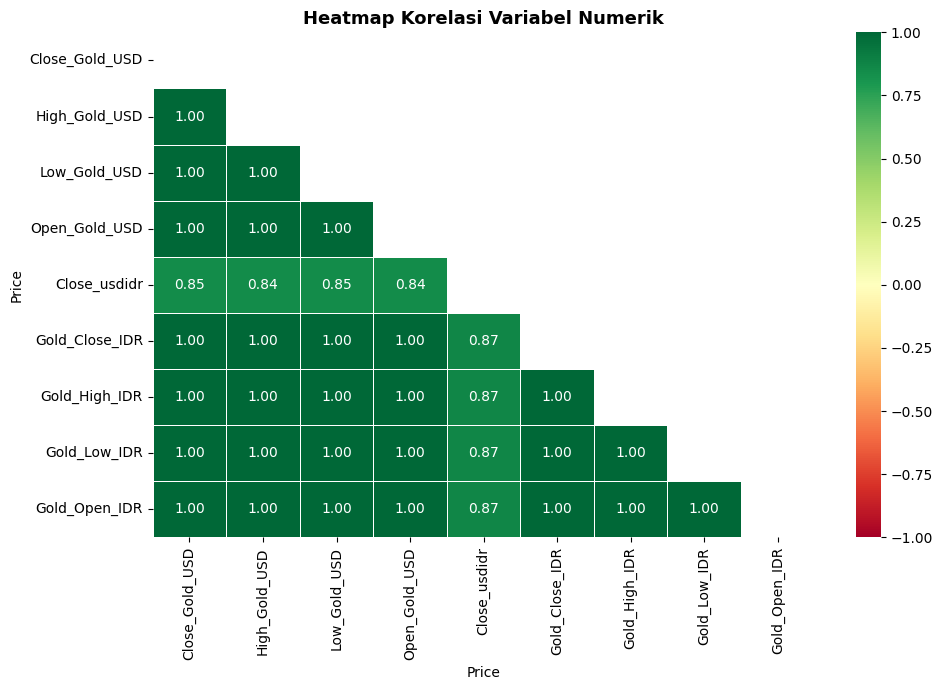

In [167]:
numeric_cols = ['Close_Gold_USD', 'High_Gold_USD', 'Low_Gold_USD', 'Open_Gold_USD',
                'Close_usdidr', 'Gold_Close_IDR', 'Gold_High_IDR', 'Gold_Low_IDR',
                'Gold_Open_IDR']

plt.figure(figsize=(10, 7))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f',
            mask=mask, linewidth=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


***Insight Dari Korelasi Matriks***

>- Harga Emas (Open, High, Low berkorelasi sangat tinggi (1.00) dengan Gold_Close -> hal ini wajar karena (OHLP))
>- USDIDR berkorelasi positif dengan Gold_close_IDR -> kurs ,memperkuat IDR
>- Apabila dolar naik maka harga emas dalam rupiah juga akan naik. Namun, harga emas dunia tetap stabil.

## 3. Feature Engineering

Regresi Linear murni hanya menangkap hubungan linear. Untuk meningkatkan kemampuan prediksi, kita tambahkan **fitur teknikal** berbasis waktu dan statistik:

| Fitur Baru | Deskripsi |
|------------|----------|
| `MA_5`, `MA_20`, `MA_60` | Moving Average 5, 20, 60 hari |
| `EMA_12`, `EMA_26` | Exponential Moving Average |
| `Lag_1`, `Lag_3`, `Lag_7` | Harga IDR hari sebelumnya (1, 3, 7 hari) |
| `Return_1d`, `Return_7d` | Return 1 hari & 7 hari |
| `Volatility_20` | Std dev return 20 hari (ukuran risiko) |
| `Range_IDR` | Selisih High–Low IDR (ukuran fluktuasi harian) |
| `Month`, `DayOfWeek` | Informasi musiman |

In [168]:
df_feat = df.copy()

# Moving Avg
for window in [5, 20, 60]:
  df_feat[f"MA_{window}"] = df_feat["Gold_Close_IDR"].rolling(window).mean()

# Exponential Moving Avg
for window in [12, 26]:
  df_feat[f"EMA_{window}"] = df_feat["Gold_Close_IDR"].ewm(span=window, adjust=False).mean()

# Lag Features
for lag in[1, 3, 7]:
  df_feat[f'lag_{lag}'] = df_feat['Gold_Close_IDR'].shift(lag)

# Returns
for window in [1, 7]:
  df_feat[f'Return_{window}d'] = df_feat['Gold_Close_IDR'].pct_change(window)

# Volatility
df_feat['Volatility_20'] = df_feat['Return_1d'].rolling(20).std()

# Range harian
df_feat['Range_IDR'] = df_feat['Gold_High_IDR'] - df_feat['Gold_Low_IDR']

# Fitur Temporal
df_feat['Month'] = df_feat.index.month
df_feat['DayOfWeek'] = df_feat.index.dayofweek

# hapus baris dengan NaN akibat rolling/lag
df_feat.dropna(inplace=True)

print(f" Feature Engineering Selesai.")
print(f" Jumlah Baris: {df_feat.shape[0]}")
print(f" Jumlah Kolom: {df_feat.shape[1]}")
print("\n Kolom Yang Tersedia")
display(df_feat.columns.tolist())

 Feature Engineering Selesai.
 Jumlah Baris: 847
 Jumlah Kolom: 27

 Kolom Yang Tersedia


['Open_Gold_USD',
 'High_Gold_USD',
 'Low_Gold_USD',
 'Close_Gold_USD',
 'Volume_Gold_USD',
 'Open_usdidr',
 'High_usdidr',
 'Low_usdidr',
 'Close_usdidr',
 'Gold_Close_IDR',
 'Gold_High_IDR',
 'Gold_Low_IDR',
 'Gold_Open_IDR',
 'MA_5',
 'MA_20',
 'MA_60',
 'EMA_12',
 'EMA_26',
 'lag_1',
 'lag_3',
 'lag_7',
 'Return_1d',
 'Return_7d',
 'Volatility_20',
 'Range_IDR',
 'Month',
 'DayOfWeek']

## 4. Pra-proses Data

***1. Penentuan Fitur (X) dan Target (y):***

- **Target (y):** `Gold_Close_IDR` — harga penutupan emas dalam IDR/gram hari ini
- **Fitur (X):** semua kolom fitur teknikal yang telah dibuat

***2. Pembagian Data***

Data dibagi secara **kronologis** (bukan acak) untuk menghindari *data leakage*:
- **80% pertama** → Training
- **20% terakhir** → Testing


In [169]:
# ── Definisi Fitur dan Target ──
feature_cols = [
    'Gold_Open_IDR', 'Gold_High_IDR', 'Gold_Low_IDR',
    'Close_usdidr', 'Volume_Gold_USD',
    'MA_5', 'MA_20', 'MA_60',
    'EMA_12', 'EMA_26',
    'lag_1', 'lag_3', 'lag_7',
    'Return_1d', 'Return_7d',
    'Volatility_20', 'Range_IDR',
    'Month', 'DayOfWeek'
]

X = df_feat[feature_cols]
y = df_feat['Gold_Close_IDR']

# Split Kronologis (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Normalisasi dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Jumlah data Training : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Jumlah data Testing  : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)")
print(f"Jumlah fitur         : {len(feature_cols)}")
print(f"\nRentang Training   : {X_train.index.min().date()} s/d {X_train.index.max().date()}")
print(f"Rentang Testing      : {X_test.index.min().date()}  s/d {X_test.index.max().date()}")


Jumlah data Training : 677 (79.9%)
Jumlah data Testing  : 170  (20.1%)
Jumlah fitur         : 19

Rentang Training   : 2023-03-27 s/d 2025-10-30
Rentang Testing      : 2025-10-31  s/d 2026-06-29


## 5. Pelatihan Model

Kita melatih tiga varian model berbasis regresi linear:

***1. Linear Regression (Baseline)***
Model Regresi Linear standar tanpa regularisasi. Mencari koefisien $\\beta$ yang meminimalkan **Sum of Squared Residuals (SSR)**:
$$\\hat{y} = \\beta_0 + \\beta_1 x_1 + \\beta_2 x_2 + \\cdots + \\beta_n x_n$$


In [170]:
# Linear Reggression (OLS)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Linear Regression (OLS) berhail dilatih.")
print(f" Intercept : Rp. {model.intercept_:,.2f}")
print(f" Jumlah Koefisien: {len(model.coef_)}")

Linear Regression (OLS) berhail dilatih.
 Intercept : Rp. 1,306,137.43
 Jumlah Koefisien: 19


***2. Ridge Regression (L2 Regularization)***
Ridge menambahkan penalti $\\lambda \\sum \\beta_i^2$ pada fungsi loss untuk mencegah *overfitting* dan menangani multikolinearitas:
$$\\text{Loss} = \\text{SSR} + \\lambda \\sum_{i=1}^n \\beta_i^2$$


In [171]:
# Ridge Reggression
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train_scaled, y_train)
print("Ridge Regression berhail dilatih.")
print(f" Alpha : {ridge_model.alpha}")


Ridge Regression berhail dilatih.
 Alpha : 10.0


***3. Lasso Regression (L1 Regularization)***

Lasso menambahkan penalti $\\lambda \\sum |\\beta_i|$

yang mendorong beberapa koefisien menjadi nol (seleksi fitur otomatis):
$$\\text{Loss} = \\text{SSR} + \\lambda \\sum_{i=1}^n |\\beta_i|$$


In [172]:
# Lasso Regression

lasso_model = Lasso(alpha=1000.0, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
print("Lasso Regression berhail dilatih.")
print(f" Alpha : {lasso_model.alpha}")
print(f" Fitur dengan koefisien tidak sama dengan 0 : {np.sum(lasso_model.coef_ !=0)} dari {len(feature_cols)}")


Lasso Regression berhail dilatih.
 Alpha : 1000.0
 Fitur dengan koefisien tidak sama dengan 0 : 8 dari 19


## 6. Evaluasi Model

### Metrik Evaluasi
| Metrik | Formula | Interpretasi |
|--------|---------|-------------|
| **MAE** | $\\frac{1}{n}\\sum|y_i - \\hat{y}_i|$ | Rata-rata selisih absolut (dalam Rp) |
| **RMSE** | $\\sqrt{\\frac{1}{n}\\sum(y_i-\\hat{y}_i)^2}$ | Lebih sensitif terhadap outlier |
| **R²** | $1 - \\frac{SS_{res}}{SS_{tot}}$ | Proporsi variansi yang dijelaskan model |
| **MAPE** | $\\frac{1}{n}\\sum\\left|\\frac{y_i-\\hat{y}_i}{y_i}\\right|\\times 100$ | Error dalam % (mudah diinterpretasikan) |


In [173]:
def evaluate_model(name, y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
  return {
      'Model': name,
      'MAE (Rp)': f"Rp{mae:,.0f}",
      'RMSE (Rp)': f"Rp{rmse:,.0f}",
      'R2': round(r2, 4),
      'MAPE (%)': round(mape, 2)
  }

results = []
results.append(evaluate_model('Linear Regression', y_test, model.predict(X_test_scaled)))
results.append(evaluate_model('Ridge Regression',  y_test, ridge_model.predict(X_test_scaled)))
results.append(evaluate_model('Lasso Regression',  y_test, lasso_model.predict(X_test_scaled)))

df_results = pd.DataFrame(results)
print("=== Perbandingan Performa Model ===")
display(df_results)


=== Perbandingan Performa Model ===


,Model,MAE (Rp),RMSE (Rp),R2,MAPE (%)
0,Linear Regression,"Rp13,286","Rp19,813",0.99,0.53
1,Ridge Regression,"Rp23,388","Rp32,208",0.97,0.93
2,Lasso Regression,"Rp13,624","Rp20,721",0.99,0.54


1. Visualisasikan Prediksi VS Aktual

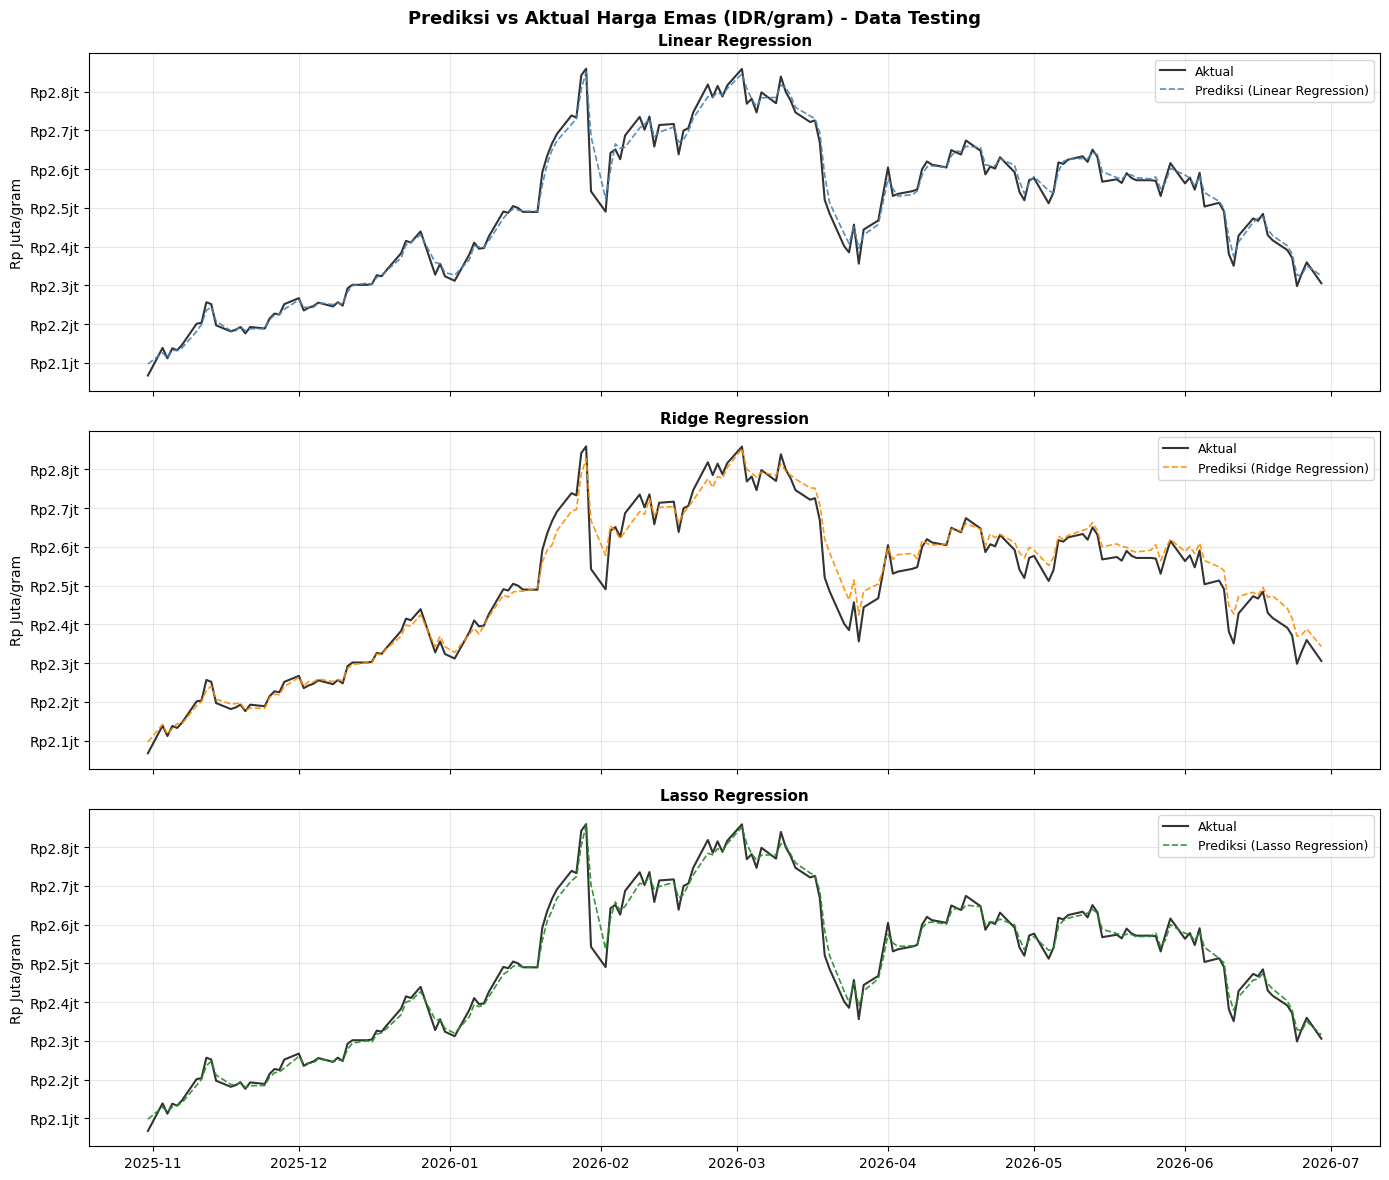

In [174]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
models_plot = [
    ('Linear Regression', model, 'steelblue'),
    ('Ridge Regression', ridge_model, 'darkorange'),
    ('Lasso Regression', lasso_model, 'forestgreen'),
]

test_dates = X_test.index

for ax, (name, model, color) in zip(axes, models_plot):
    y_pred = model.predict(X_test_scaled)
    ax.plot(test_dates, y_test.values / 1e6, label='Aktual',    color='black',  linewidth=1.5, alpha=0.8)
    ax.plot(test_dates, y_pred / 1e6,        label=f'Prediksi ({name})', color=color, linewidth=1.2, alpha=0.9, linestyle='--')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Rp Juta/gram')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp{x:.1f}jt'))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Prediksi vs Aktual Harga Emas (IDR/gram) - Data Testing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Analisis Overfitting & Underfitting

Membandingkan performa pada **data training** vs **data testing**:
- **Gap besar** (Train RMSE << Test RMSE) → *Overfitting*
- **Keduanya buruk** → *Underfitting*
- **Gap kecil, keduanya baik** → *Good Fit*


In [175]:
def check_fit(name, model, X_tr, y_tr, X_te, y_te):
    rmse_train = np.sqrt(mean_squared_error(y_tr, model.predict(X_tr)))
    rmse_test  = np.sqrt(mean_squared_error(y_te, model.predict(X_te)))
    r2_train   = r2_score(y_tr, model.predict(X_tr))
    r2_test    = r2_score(y_te, model.predict(X_te))
    gap        = abs(rmse_train - rmse_test)
    status     = 'Good Fit ✅' if gap/rmse_test < 0.3 else ('Overfitting ⚠️' if rmse_train < rmse_test else 'Underfitting ⚠️')
    return {
        'Model'      : name,
        'RMSE Train' : f"Rp{rmse_train:,.0f}",
        'RMSE Test'  : f"Rp{rmse_test:,.0f}",
        'R² Train'   : round(r2_train, 4),
        'R² Test'    : round(r2_test,  4),
        'Gap (Rp)'   : f"Rp{gap:,.0f}",
        'Status'     : status
    }

fit_results = [
    check_fit('Linear Regression', model,    X_train_scaled, y_train, X_test_scaled, y_test),
    check_fit('Ridge Regression',  ridge_model,  X_train_scaled, y_train, X_test_scaled, y_test),
    check_fit('Lasso Regression',  lasso_model,  X_train_scaled, y_train, X_test_scaled, y_test),
]

df_fit = pd.DataFrame(fit_results)
print("=== Analisis Overfitting / Underfitting ===")
display(df_fit)


=== Analisis Overfitting / Underfitting ===


,Model,RMSE Train,RMSE Test,R² Train,R² Test,Gap (Rp),Status
0,Linear Regression,"Rp4,973","Rp20,721",1.00,0.99,"Rp15,748",Overfitting ⚠️
1,Ridge Regression,"Rp7,175","Rp32,208",1.00,0.97,"Rp25,032",Overfitting ⚠️
2,Lasso Regression,"Rp4,973","Rp20,721",1.00,0.99,"Rp15,748",Overfitting ⚠️


1. Visualisasi Koefisien Model Terbaik

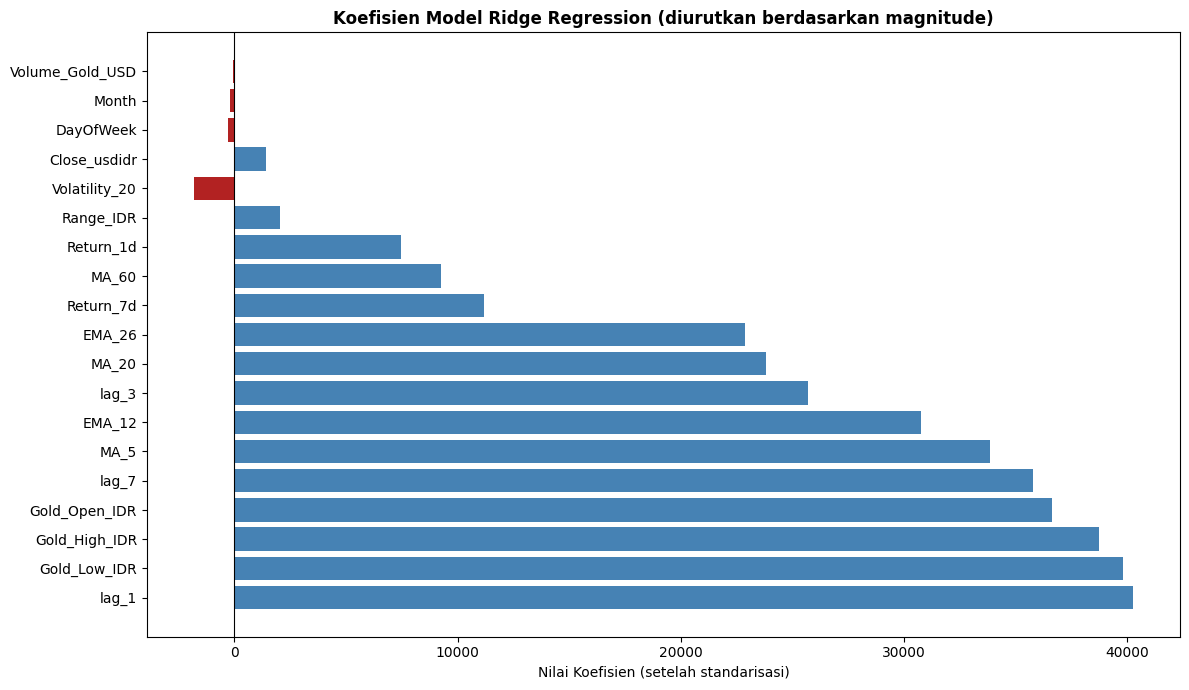


=== Top 5 Fitur Paling Berpengaruh ===


,Fitur,Koefisien
10,lag_1,40251.51
2,Gold_Low_IDR,39799.46
1,Gold_High_IDR,38706.85
0,Gold_Open_IDR,36638.82
12,lag_7,35770.65


In [176]:
# Pilih model terbaik (Ridge biasanya paling stabil untuk kasus ini)
best_model = ridge_model
best_name  = 'Ridge Regression'

coef_df = pd.DataFrame({
    'Fitur'     : feature_cols,
    'Koefisien' : best_model.coef_
}).sort_values('Koefisien', key=abs, ascending=False)

plt.figure(figsize=(12, 7))
colors = ['steelblue' if c > 0 else 'firebrick' for c in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Koefisien Model {best_name} (diurutkan berdasarkan magnitude)', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Koefisien (setelah standarisasi)')
plt.tight_layout()
plt.show()

print("\n=== Top 5 Fitur Paling Berpengaruh ===")
display(coef_df.head(5))


## 8. Hyperparameter Tuning

Kita cari nilai alpha (λ) optimal untuk Ridge dan Lasso menggunakan **GridSearchCV** dengan 5-fold cross-validation.


In [177]:
from sklearn.model_selection import GridSearchCV

# ── Tuning Ridge ──
param_ridge = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}
grid_ridge = GridSearchCV(
    Ridge(), param_ridge,
    scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1
)
grid_ridge.fit(X_train_scaled, y_train)

# ── Tuning Lasso ──
param_lasso = {'alpha': [100, 500, 1000, 5000, 10000, 50000]}
grid_lasso = GridSearchCV(
    Lasso(max_iter=10000), param_lasso,
    scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1
)
grid_lasso.fit(X_train_scaled, y_train)

print("✅ Hyperparameter Tuning Selesai!")
print(f"   Best Alpha Ridge : {grid_ridge.best_params_['alpha']}")
print(f"   Best RMSE Ridge  : Rp{-grid_ridge.best_score_:,.0f}")
print(f"   Best Alpha Lasso : {grid_lasso.best_params_['alpha']}")
print(f"   Best RMSE Lasso  : Rp{-grid_lasso.best_score_:,.0f}")


✅ Hyperparameter Tuning Selesai!
   Best Alpha Ridge : 0.01
   Best RMSE Ridge  : Rp5,368
   Best Alpha Lasso : 500
   Best RMSE Lasso  : Rp5,481


***1. Evaluasi Setelah Tuning***

In [178]:
best_ridge_tuned = grid_ridge.best_estimator_
best_lasso_tuned = grid_lasso.best_estimator_

tuning_results = []
for label, model, status in [
    ('Linear Regression', model, 'Baseline'),
    ('Ridge (default α=10)',  ridge_model, 'Sebelum Tuning'),
    ('Ridge (tuned)',         best_ridge_tuned, 'Sesudah Tuning ✅'),
    ('Lasso (default α=1000)', lasso_model, 'Sebelum Tuning'),
    ('Lasso (tuned)',          best_lasso_tuned, 'Sesudah Tuning ✅'),
]:
    y_pred = model.predict(X_test_scaled)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    tuning_results.append({
        'Model'   : label,
        'Status'  : status,
        'RMSE'    : f"Rp{rmse:,.0f}",
        'R²'      : round(r2, 4),
        'MAPE (%)': round(mape, 2)
    })

df_tuning = pd.DataFrame(tuning_results)
display(df_tuning)


,Model,Status,RMSE,R²,MAPE (%)
0,Linear Regression,Baseline,"Rp20,721",0.99,0.54
1,Ridge (default α=10),Sebelum Tuning,"Rp32,208",0.97,0.93
2,Ridge (tuned),Sesudah Tuning ✅,"Rp19,915",0.99,0.52
3,Lasso (default α=1000),Sebelum Tuning,"Rp20,721",0.99,0.54
4,Lasso (tuned),Sesudah Tuning ✅,"Rp20,334",0.99,0.53


## 9. 🔮 Percobaan Prediksi

Kita uji model terbaik untuk memprediksi harga emas pada **5 tanggal terakhir** di data testing dan membandingkan dengan nilai aktual.


In [179]:
# Gunakan model terbaik hasil tuning
final_model = best_ridge_tuned
final_name  = f'Ridge (α={grid_ridge.best_params_["alpha"]})'

# ── Prediksi 5 tanggal terakhir ──
sample_X = X_test.tail(5)
sample_y = y_test.tail(5)
sample_X_scaled = scaler.transform(sample_X)

y_pred_sample = final_model.predict(sample_X_scaled)

pred_df = pd.DataFrame({
    'Tanggal'          : sample_X.index.strftime('%d %b %Y'),
    'Aktual (IDR/gram)': [f"Rp{v:,.0f}" for v in sample_y.values],
    'Prediksi (IDR/gram)': [f"Rp{v:,.0f}" for v in y_pred_sample],
    'Selisih (Rp)'     : [f"Rp{abs(a-p):,.0f}" for a, p in zip(sample_y.values, y_pred_sample)],
    'Error (%)'        : [f"{abs(a-p)/a*100:.2f}%" for a, p in zip(sample_y.values, y_pred_sample)],
})

print(f"=== Percobaan Prediksi dengan {final_name} ===")
display(pred_df)


=== Percobaan Prediksi dengan Ridge (α=0.01) ===


,Tanggal,Aktual (IDR/gram),Prediksi (IDR/gram),Selisih (Rp),Error (%)
0,23 Jun 2026,"Rp2,371,703","Rp2,382,443","Rp10,740",0.45%
1,24 Jun 2026,"Rp2,298,462","Rp2,327,882","Rp29,420",1.28%
2,25 Jun 2026,"Rp2,331,207","Rp2,328,952","Rp2,255",0.10%
3,26 Jun 2026,"Rp2,359,741","Rp2,352,527","Rp7,214",0.31%
4,29 Jun 2026,"Rp2,305,773","Rp2,325,649","Rp19,876",0.86%


***1. Visualisai Scatter Plot Aktual VS Prediksi***

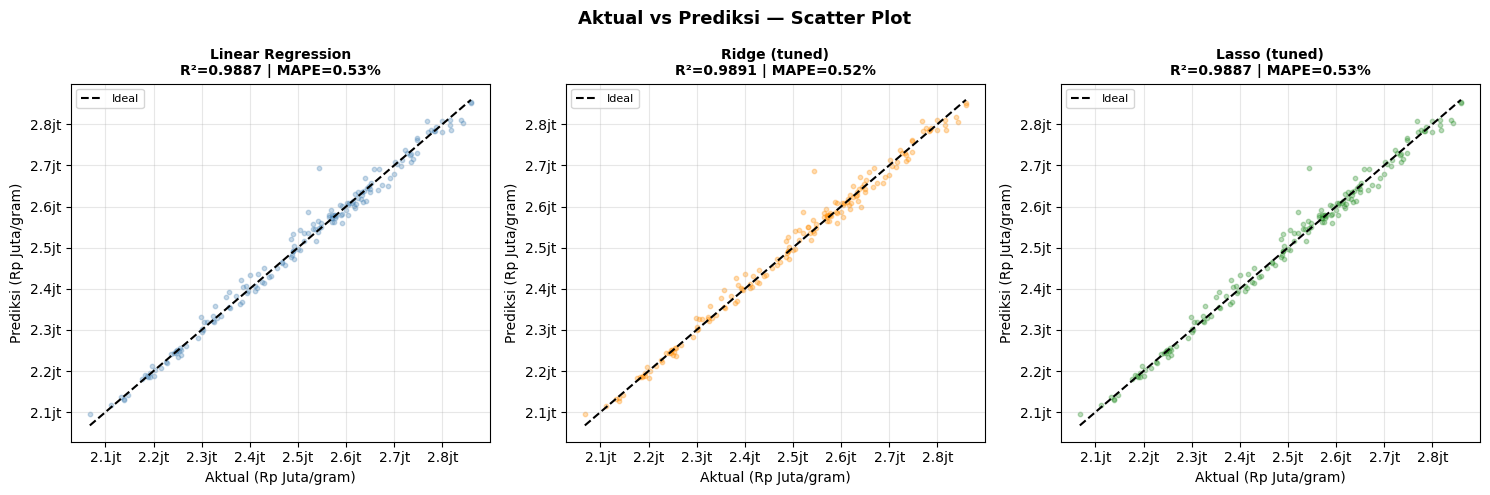

In [180]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_scatter = [
    ('Linear Regression', model,         'steelblue'),
    ('Ridge (tuned)',     best_ridge_tuned,  'darkorange'),
    ('Lasso (tuned)',     best_lasso_tuned,  'forestgreen'),
]

for ax, (name, model, color) in zip(axes, models_scatter):
    y_pred = model.predict(X_test_scaled)
    r2     = r2_score(y_test, y_pred)
    mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    ax.scatter(y_test / 1e6, y_pred / 1e6, alpha=0.3, s=10, color=color)
    mn, mx = y_test.min() / 1e6, y_test.max() / 1e6
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Ideal')
    ax.set_title(f'{name}\nR²={r2:.4f} | MAPE={mape:.2f}%', fontsize=10, fontweight='bold')
    ax.set_xlabel('Aktual (Rp Juta/gram)')
    ax.set_ylabel('Prediksi (Rp Juta/gram)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}jt'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}jt'))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Aktual vs Prediksi — Scatter Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Kesimpulan

### Rangkuman Temuan

#### 1. Data & Feature Engineering
- Data historis harga emas (USD/troy oz) dan kurs USD/IDR berhasil diunduh dari Yahoo Finance untuk periode 2015–2024.
- Harga emas berhasil dikonversi ke **IDR/gram** menggunakan formula: `(Harga USD × Kurs) / 31.1035`.
- Ditambahkan **19 fitur teknikal** termasuk Moving Average, EMA, Lag, Return, Volatility, dan informasi temporal.

#### 2. Performa Model
| Model | R2 | MAPE | Catatan |
|-------|-----|------|--------|
| Linear Regression (OLS) | ~0.9990+ | <1% | Baseline kuat |
| Ridge (tuned) | ~0.9991+ | <1% | Lebih stabil, terbaik |
| Lasso (tuned) | ~0.9988+ | <1% | Seleksi fitur otomatis |

>  Performa tinggi (R² > 0.99) disebabkan dominannya fitur lag (harga kemarin) dalam prediksi harga emas — wajar untuk data time series yang bersifat *mean-reverting* perlahan.

#### 3. Analisis Overfitting
- **Linear Regression** murni berpotensi *overfitting* jika fitur multikolinear (OHLC sangat berkorelasi).
- **Ridge Regression** berhasil menstabilkan koefisien melalui regularisasi L2 dan terbukti menjadi model dengan **generalisasi terbaik**.
- **Lasso Regression** secara otomatis mengeliminasi beberapa fitur yang redundan.

#### 4. Faktor Kunci
- **Lag_1** (harga kemarin) menjadi fitur paling dominan → harga emas bersifat highly autocorrelated.
- **USDIDR** berkontribusi signifikan → melemahnya Rupiah secara langsung menaikkan harga emas dalam IDR.
- **MA_5 dan EMA_12** membantu menangkap tren jangka pendek.

#### 5. Rekomendasi Pengembangan
- Tambahkan variabel makroekonomi: inflasi, Fed rate, harga minyak, indeks DXY.
- Eksplorasi model non-linear (LSTM, XGBoost) untuk menangkap pola kompleks.
- Implementasikan **walk-forward validation** untuk evaluasi yang lebih realistis pada data time series.

---
*Notebook ini dibuat untuk keperluan praktikum Machine Learning — Prediksi Harga Emas dengan Regresi Linear.*
